In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
from pathlib import Path

DATA_PATH = Path('tryout.csv')  # assumes notebook is run from this folder

df = pd.read_csv(DATA_PATH)
print('df.shape =', df.shape)
df.head()


df.shape = (60, 18)


,id,createdAt,sessionid,pairid,secElasped,chosen,order,mindChanged,l_elderlyDep,l_lifeYearsGained,l_obesity,l_weeklyWorkhours,l_yearsWaiting,r_elderlyDep,r_lifeYearsGained,r_obesity,r_weeklyWorkhours,r_yearsWaiting
0,1,36:00.9,10eb4618-36b7-43fa-9b14-ffd525365d47,0-10-5-4-0_1-25-3-0-0,26,0,59,0,0,10,4,0,5,1,25,0,0,3
1,1,30:39.9,10eb4618-36b7-43fa-9b14-ffd525365d47,0-20-1-1-50_3-20-5-1-30,7,0,32,0,0,20,1,50,1,3,20,1,30,5
2,1,31:43.9,10eb4618-36b7-43fa-9b14-ffd525365d47,0-20-5-3-20_0-20-3-0-30,15,1,36,0,0,20,3,20,5,0,20,0,30,3
3,1,34:28.0,10eb4618-36b7-43fa-9b14-ffd525365d47,0-25-1-3-20_2-5-5-4-0,18,0,51,0,0,25,3,20,1,2,5,4,0,5
4,1,34:47.1,10eb4618-36b7-43fa-9b14-ffd525365d47,0-25-1-3-20_3-5-5-3-20,5,0,54,0,0,25,3,20,1,3,5,3,20,5


In [3]:
# Extract per-row feature vectors for the left and right option (in your requested order)

LEFT_COLS = [
    'l_elderlyDep',
    'l_lifeYearsGained',
    'l_obesity',
    'l_weeklyWorkhours',
    'l_yearsWaiting',
]
RIGHT_COLS = [
    'r_elderlyDep',
    'r_lifeYearsGained',
    'r_obesity',
    'r_weeklyWorkhours',
    'r_yearsWaiting',
]

# Row-wise vectors (python lists)
df['x_l'] = df[LEFT_COLS].values.tolist()
df['x_r'] = df[RIGHT_COLS].values.tolist()

# Matrix versions (numpy arrays), one row per comparison
X_l = df[LEFT_COLS].to_numpy()
X_r = df[RIGHT_COLS].to_numpy()

print('X_l shape:', X_l.shape, 'X_r shape:', X_r.shape)

# Show a quick sanity check for the first few rows
cols_to_show = ['id', 'pairid'] + LEFT_COLS + RIGHT_COLS + ['x_l', 'x_r']
df[cols_to_show].head()


X_l shape: (60, 5) X_r shape: (60, 5)


,id,pairid,l_elderlyDep,l_lifeYearsGained,l_obesity,l_weeklyWorkhours,l_yearsWaiting,r_elderlyDep,r_lifeYearsGained,r_obesity,r_weeklyWorkhours,r_yearsWaiting,x_l,x_r
0,1,0-10-5-4-0_1-25-3-0-0,0,10,4,0,5,1,25,0,0,3,"[0, 10, 4, 0, 5]","[1, 25, 0, 0, 3]"
1,1,0-20-1-1-50_3-20-5-1-30,0,20,1,50,1,3,20,1,30,5,"[0, 20, 1, 50, 1]","[3, 20, 1, 30, 5]"
2,1,0-20-5-3-20_0-20-3-0-30,0,20,3,20,5,0,20,0,30,3,"[0, 20, 3, 20, 5]","[0, 20, 0, 30, 3]"
3,1,0-25-1-3-20_2-5-5-4-0,0,25,3,20,1,2,5,4,0,5,"[0, 25, 3, 20, 1]","[2, 5, 4, 0, 5]"
4,1,0-25-1-3-20_3-5-5-3-20,0,25,3,20,1,3,5,3,20,5,"[0, 25, 3, 20, 1]","[3, 5, 3, 20, 5]"


In [4]:
# Halfspace constraints from choices (STRICT inequalities)
# Define Δ = x_l - x_r.
# If chosen == 0 (left chosen):   θ · Δ > 0
# If chosen == 1 (right chosen):  θ · Δ < 0

# Matrix differences
Delta_lr = X_l - X_r          # Δ = x_l - x_r
Delta_rl = X_r - X_l          # x_r - x_l (since you also asked for that subtraction)

df['delta_lr'] = Delta_lr.tolist()
df['delta_rl'] = Delta_rl.tolist()

if not set(df['chosen'].dropna().unique()).issubset({0, 1}):
    raise ValueError(f"Expected 'chosen' to be 0/1. Got: {sorted(df['chosen'].unique())}")

# Halfspace sense, exactly as stated (strict)
df['halfspace_sense_strict'] = np.where(df['chosen'].to_numpy(dtype=int) == 0, '> 0', '< 0')

# Standardized strict form: always a_i · θ > 0
# - if chosen==0: a =  Δ
# - if chosen==1: a = -Δ  (equivalent to θ·Δ < 0)
A = np.where(df['chosen'].to_numpy(dtype=int).reshape(-1, 1) == 0, Delta_lr, -Delta_lr)
df['halfspace_normal_a'] = A.tolist()


def fmt_vec(v):
    return '[' + ', '.join(f'{x:g}' for x in v) + ']'

# Show a few constraints
preview_cols = ['id', 'pairid', 'chosen', 'x_l', 'x_r', 'delta_lr', 'halfspace_sense_strict', 'halfspace_normal_a']
display(df[preview_cols].head())

print('Interpretation per row (strict):')
print('- if chosen==0:  θ · (x_l - x_r) > 0')
print('- if chosen==1:  θ · (x_l - x_r) < 0   (equivalently: (- (x_l - x_r)) · θ > 0)')
print('Standardized:  a · θ > 0  for every row, where a = halfspace_normal_a')
print('\nExample (row 0):')
row0 = df.iloc[0]
print('Δ = x_l - x_r =', fmt_vec(row0['delta_lr']))
print('constraint:', f"θ · Δ {row0['halfspace_sense_strict']}")
print('standard form a · θ > 0, with a =', fmt_vec(row0['halfspace_normal_a']))



,id,pairid,chosen,x_l,x_r,delta_lr,halfspace_sense_strict,halfspace_normal_a
0,1,0-10-5-4-0_1-25-3-0-0,0,"[0, 10, 4, 0, 5]","[1, 25, 0, 0, 3]","[-1, -15, 4, 0, 2]",> 0,"[-1, -15, 4, 0, 2]"
1,1,0-20-1-1-50_3-20-5-1-30,0,"[0, 20, 1, 50, 1]","[3, 20, 1, 30, 5]","[-3, 0, 0, 20, -4]",> 0,"[-3, 0, 0, 20, -4]"
2,1,0-20-5-3-20_0-20-3-0-30,1,"[0, 20, 3, 20, 5]","[0, 20, 0, 30, 3]","[0, 0, 3, -10, 2]",< 0,"[0, 0, -3, 10, -2]"
3,1,0-25-1-3-20_2-5-5-4-0,0,"[0, 25, 3, 20, 1]","[2, 5, 4, 0, 5]","[-2, 20, -1, 20, -4]",> 0,"[-2, 20, -1, 20, -4]"
4,1,0-25-1-3-20_3-5-5-3-20,0,"[0, 25, 3, 20, 1]","[3, 5, 3, 20, 5]","[-3, 20, 0, 0, -4]",> 0,"[-3, 20, 0, 0, -4]"


Interpretation per row (strict):
- if chosen==0:  θ · (x_l - x_r) > 0
- if chosen==1:  θ · (x_l - x_r) < 0   (equivalently: (- (x_l - x_r)) · θ > 0)
Standardized:  a · θ > 0  for every row, where a = halfspace_normal_a

Example (row 0):
Δ = x_l - x_r = [-1, -15, 4, 0, 2]
constraint: θ · Δ > 0
standard form a · θ > 0, with a = [-1, -15, 4, 0, 2]


In [ ]:
# Certified intersection check for STRICT halfspaces: a_i · theta > 0 for all i
# We solve:
#   maximize eps
#   s.t.   A @ theta >= eps   (componentwise)
#          ||theta||_1 = 1    (to remove scaling ambiguity)
# If the optimum eps > 0, the strict intersection is non-empty; we output such a theta.

try:
    from scipy.optimize import linprog
except Exception as e:
    raise ImportError(
        "SciPy is required for the certified intersection check in this cell (pip install scipy)."
    ) from e

A_np = np.asarray(A, dtype=float)
if np.isnan(A_np).any():
    raise ValueError('A contains NaNs; cannot run certified check.')

m, d = A_np.shape

# Variables: theta_plus (d), theta_minus (d), eps (1)
# theta = theta_plus - theta_minus, theta_plus, theta_minus >= 0
num_vars = 2 * d + 1

# Objective: minimize -eps  (i.e., maximize eps)
c = np.zeros(num_vars)
c[-1] = -1.0

# Inequalities: A @ (theta_plus - theta_minus) - eps >= 0
# Convert to A_ub x <= b_ub:
#   -A@theta_plus + A@theta_minus + eps <= 0
A_ub = np.zeros((m, num_vars))
A_ub[:, :d] = -A_np
A_ub[:, d:2*d] = A_np
A_ub[:, -1] = 1.0
b_ub = np.zeros(m)

# Equality: ||theta||_1 = sum(theta_plus + theta_minus) = 1
A_eq = np.zeros((1, num_vars))
A_eq[0, :2*d] = 1.0
b_eq = np.array([1.0])

# Bounds: theta_plus/theta_minus >= 0; eps free
bounds = [(0.0, None)] * (2 * d) + [(None, None)]

res = linprog(
    c,
    A_ub=A_ub,
    b_ub=b_ub,
    A_eq=A_eq,
    b_eq=b_eq,
    bounds=bounds,
    method='highs',
)

print('LP success:', res.success)
print('LP status:', res.status)
print('LP message:', res.message)

if not res.success:
    print('Result: could not certify (solver failure).')
else:
    theta_plus = res.x[:d]
    theta_minus = res.x[d:2*d]
    theta = theta_plus - theta_minus
    eps = float(res.x[-1])
    margins = A_np @ theta

    print('max eps:', eps)
    print('min_i (a_i · theta):', float(margins.min()))

    if eps > 1e-9:
        print('\nIntersection of STRICT halfspaces: NON-EMPTY')
        print('one feasible theta (||theta||_1 = 1):', theta)

        # Optional: rescale so that min margin is 1 (i.e., A @ theta >= 1)
        theta_scaled = theta / eps
        print('scaled theta (min margin = 1):', theta_scaled)
    else:
        print('\nIntersection of STRICT halfspaces: EMPTY')
        print('(You may still have a non-strict solution with >= 0, but no solution with > 0.)')



LP success: True
LP status: 0
LP message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
max eps: -0.0
min_i (a_i · theta): 0.0

Intersection of STRICT halfspaces: EMPTY
(You may still have a non-strict solution with >= 0, but no solution with > 0.)


In [6]:
# Sampling-based “spread” of feasible thetas
#
# For each repetition:
# - sample k comparisons uniformly at random
# - build strict halfspaces a_i · theta > 0 for those k
# - if feasible, output a theta (normalized with ||theta||_1 = 1)
# - if infeasible (no strict solution), resample
#
# Repeat this m times to see the spread of feasible thetas.

try:
    from scipy.optimize import linprog
except Exception as e:
    raise ImportError("This cell needs SciPy (pip install scipy).") from e

# Adjustable parameters
k = 10          # number of sampled comparisons per run
m_runs = 50     # number of successful thetas to generate
seed = 0
max_resamples_per_run = 500
strict_tol = 1e-9

feature_names = LEFT_COLS  # same order as theta coordinates

rng = np.random.default_rng(seed)

# Precompute full standardized normals A_all for strict constraints a·theta > 0
# (Same construction as cell above; kept explicit here for clarity.)
Delta_lr_all = X_l - X_r
A_all = np.where(df['chosen'].to_numpy(dtype=int).reshape(-1, 1) == 0, Delta_lr_all, -Delta_lr_all)
A_all = np.asarray(A_all, dtype=float)


def solve_strict_theta(A_sub: np.ndarray) -> tuple[np.ndarray | None, float | None]:
    """Return (theta, eps) for strict feasibility using max-margin LP with ||theta||_1=1.

    If eps <= 0, there is no theta with all a_i·theta > 0.
    """
    if A_sub.ndim != 2:
        raise ValueError('A_sub must be 2D')
    m_c, d_c = A_sub.shape

    # Variables: theta_plus (d), theta_minus (d), eps (1)
    num_vars = 2 * d_c + 1
    c = np.zeros(num_vars)
    c[-1] = -1.0  # maximize eps

    # Constraints: A_sub @ (theta_plus - theta_minus) - eps >= 0
    # Convert to A_ub x <= b_ub:
    #   -A_sub@theta_plus + A_sub@theta_minus + eps <= 0
    A_ub = np.zeros((m_c, num_vars))
    A_ub[:, :d_c] = -A_sub
    A_ub[:, d_c:2*d_c] = A_sub
    A_ub[:, -1] = 1.0
    b_ub = np.zeros(m_c)

    # ||theta||_1 = 1
    A_eq = np.zeros((1, num_vars))
    A_eq[0, :2*d_c] = 1.0
    b_eq = np.array([1.0])

    bounds = [(0.0, None)] * (2 * d_c) + [(None, None)]

    res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')
    if not res.success:
        return None, None

    theta_plus = res.x[:d_c]
    theta_minus = res.x[d_c:2*d_c]
    theta = theta_plus - theta_minus
    eps = float(res.x[-1])

    return theta, eps


# Run the sampling experiment
samples = []
resample_counts = []

n_total = A_all.shape[0]

for run_idx in range(m_runs):
    theta_found = None
    eps_found = None
    tried = 0

    while tried < max_resamples_per_run:
        tried += 1
        idx = rng.choice(n_total, size=k, replace=False)
        A_sub = A_all[idx]
        theta, eps = solve_strict_theta(A_sub)
        if theta is None:
            continue
        if eps is None or eps <= strict_tol:
            continue

        theta_found = theta
        eps_found = eps
        break

    if theta_found is None:
        raise RuntimeError(
            f"Failed to find a strict-feasible subset after {max_resamples_per_run} resamples (run {run_idx}). "
            "Try reducing k or increasing max_resamples_per_run."
        )

    samples.append({
        'run': run_idx,
        'k': k,
        'eps': eps_found,
        **{f'theta_{name}': float(val) for name, val in zip(feature_names, theta_found)},
    })
    resample_counts.append(tried - 1)

samples_df = pd.DataFrame(samples)

print('Generated', len(samples_df), 'feasible thetas')
print('Average resamples per successful run:', float(np.mean(resample_counts)))
print('\nTheta columns:')
print([c for c in samples_df.columns if c.startswith('theta_')])

# Quick numeric summary
theta_cols = [c for c in samples_df.columns if c.startswith('theta_')]
summary = samples_df[theta_cols + ['eps']].describe().T[['mean', 'std', 'min', 'max']]
summary



Generated 50 feasible thetas
Average resamples per successful run: 0.22

Theta columns:
['theta_l_elderlyDep', 'theta_l_lifeYearsGained', 'theta_l_obesity', 'theta_l_weeklyWorkhours', 'theta_l_yearsWaiting']


,mean,std,min,max
theta_l_elderlyDep,-0.095203,0.355794,-0.865385,0.750689
theta_l_lifeYearsGained,0.112295,0.215921,-0.384615,0.800000
theta_l_obesity,-0.008367,0.293220,-0.705882,0.890411
theta_l_weeklyWorkhours,0.123959,0.113768,0.007953,0.512195
theta_l_yearsWaiting,0.234263,0.290672,-0.862069,0.833333
eps,1.011733,0.814665,0.019120,3.035714


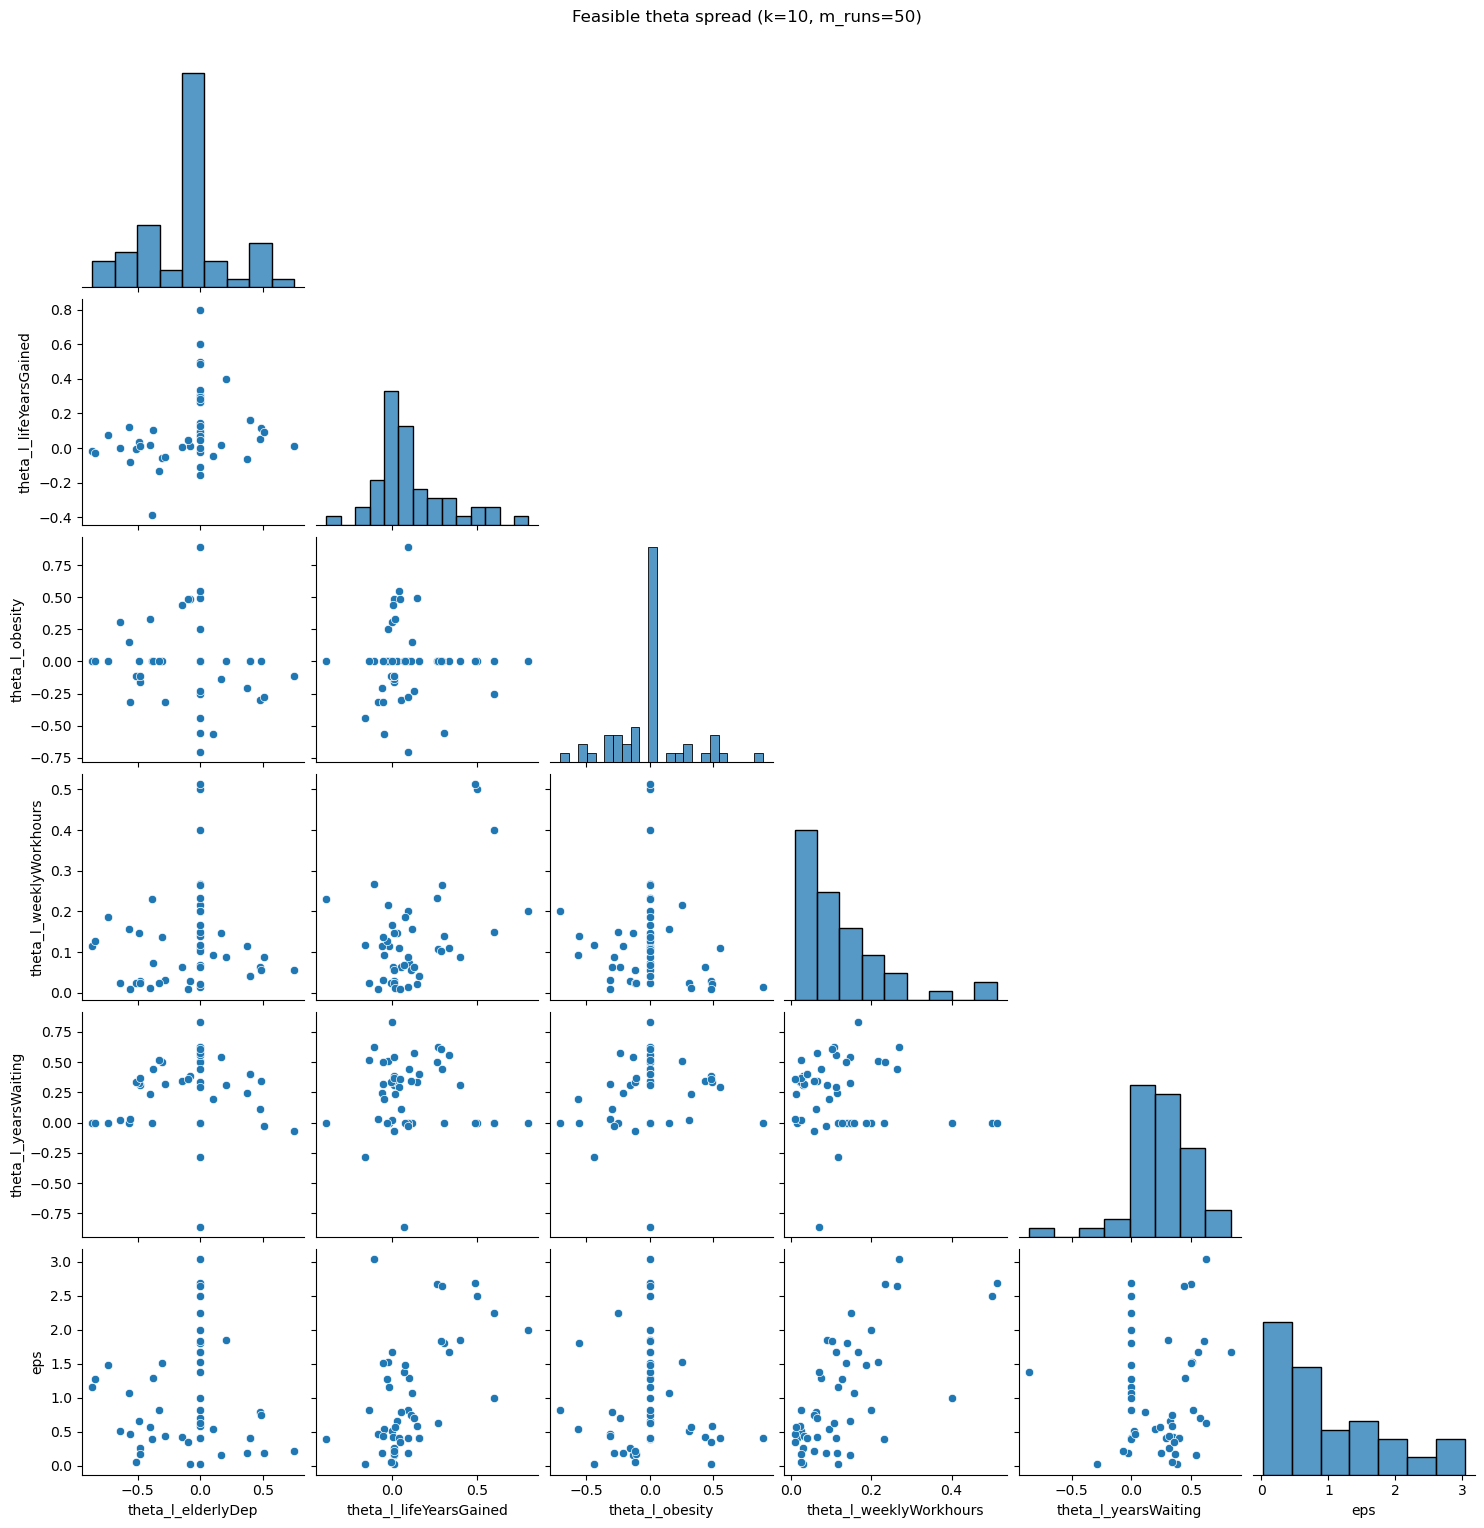

In [7]:
# Optional: quick visualization of the spread

# Pairplot of theta coordinates (can be a bit slow for large m_runs)
plot_df = samples_df[[c for c in samples_df.columns if c.startswith('theta_')] + ['eps']].copy()

sns.pairplot(plot_df, corner=True)
plt.suptitle(f"Feasible theta spread (k={k}, m_runs={m_runs})", y=1.02)
plt.show()

